# Space Weather

Two long, freely-available records:

- **SILSO daily sunspot numbers** (Royal Observatory of Belgium, v2.0 series), 1818–present
- **GFZ Potsdam Kp/ap/Ap + SN + F10.7** (Niemegk Observatory), 1932–present

Run `python fetch_spaceweather.py` first to populate `spaceweather.sqlite`.
This notebook reads from there and writes its plots to `figures/`.

In [1]:
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DB = Path("spaceweather.sqlite")
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

conn = sqlite3.connect(DB)

silso = pd.read_sql_query(
    "SELECT date_iso AS date, sunspot_number, n_obs "
    "FROM silso_daily WHERE sunspot_number >= 0",
    conn, parse_dates=["date"],
).set_index("date")

gfz = pd.read_sql_query(
    "SELECT date_iso AS date, "
    "       kp1, kp2, kp3, kp4, kp5, kp6, kp7, kp8, "
    "       ap_daily, sunspot_number, f107_obs, f107_adj "
    "FROM gfz_daily",
    conn, parse_dates=["date"],
).set_index("date")

# Peak Kp across the eight three-hour intervals each day.
KP_COLS = ["kp1", "kp2", "kp3", "kp4", "kp5", "kp6", "kp7", "kp8"]
gfz["kp_max"] = gfz[KP_COLS].max(axis=1)

# Solar cycle minima (start months) per SIDC. Cycle N runs from minimum N to N+1.
CYCLE_MINIMA = [
    (1, "1755-02"), (2, "1766-06"), (3, "1775-06"), (4, "1784-09"),
    (5, "1798-04"), (6, "1810-07"), (7, "1823-05"), (8, "1833-11"),
    (9, "1843-07"), (10, "1855-12"), (11, "1867-03"), (12, "1878-12"),
    (13, "1890-03"), (14, "1902-01"), (15, "1913-08"), (16, "1923-08"),
    (17, "1933-09"), (18, "1944-02"), (19, "1954-04"), (20, "1964-10"),
    (21, "1976-03"), (22, "1986-09"), (23, "1996-08"), (24, "2008-12"),
    (25, "2019-12"),
]

def annotate_cycles(ax, *, x_kind="date", shade=True, label_y=0.97,
                    color="#666666"):
    """Mark solar cycle boundaries on a time-axis plot.

    x_kind="date": x-axis is matplotlib dates / pandas Timestamps
    x_kind="year": x-axis is integer years

    Draws a thin vertical line at each minimum, alternates light shading
    between odd-numbered cycles, and labels each cycle by number along the
    top. Labels whose midpoint falls outside the visible x-range are skipped.
    """
    import matplotlib.dates as mdates

    def to_x(t):
        return t.year + (t.month - 1) / 12 if x_kind == "year" else t

    def to_num(x):
        return x if x_kind == "year" else mdates.date2num(x)

    xlo, xhi = ax.get_xlim()

    end_t = pd.Timestamp.today()
    bounds = [(num, to_x(pd.Timestamp(ts))) for num, ts in CYCLE_MINIMA]
    bounds.append((None, to_x(end_t)))

    for i in range(len(bounds) - 1):
        num, x = bounds[i]
        _, next_x = bounds[i + 1]
        x_num = to_num(x)
        next_num = to_num(next_x)

        # Skip cycles entirely outside the visible range
        if next_num < xlo or x_num > xhi:
            continue

        # Vertical line at the minimum
        if xlo <= x_num <= xhi:
            ax.axvline(x, color=color, ls=":", lw=0.8, alpha=0.7, zorder=0)

        # Alternating background shading on odd-numbered cycles
        if shade and num is not None and num % 2 == 1:
            ax.axvspan(x, next_x, color=color, alpha=0.10, zorder=0)

        # Cycle-number label, centered between minima
        if num is not None:
            mid_num = (x_num + next_num) / 2
            if not (xlo <= mid_num <= xhi):
                continue
            if x_kind == "year":
                mid = mid_num
            else:
                mid = x + (next_x - x) / 2
            ax.text(mid, label_y, str(num),
                    transform=ax.get_xaxis_transform(),
                    ha="center", va="top", fontsize=8,
                    color="#444444",
                    bbox=dict(boxstyle="square,pad=0.1",
                              facecolor="white", alpha=0.7,
                              edgecolor="none"))

print(f"SILSO observation days: {len(silso):,} ({silso.index.min().date()} → {silso.index.max().date()})")
print(f"GFZ daily records:      {len(gfz):,} ({gfz.index.min().date()} → {gfz.index.max().date()})")


SILSO observation days: 72,844 (1818-01-08 → 2026-04-30)
GFZ daily records:      34,470 (1932-01-01 → 2026-05-16)


## 1. Sunspot number, 1818–present

The 11-year solar cycle. Plotting daily values from 1818 makes the pre-1849
data sparsity visible — gappy, low counts not because the Sun was quiet but
because daily global observation hadn't been organized yet.

Smoothed series uses the standard SIDC convention: monthly means, then a
13-month centered running mean.

Vertical dotted lines mark SIDC's official solar minima; the small number at
the top of each shaded/unshaded band is the cycle number.

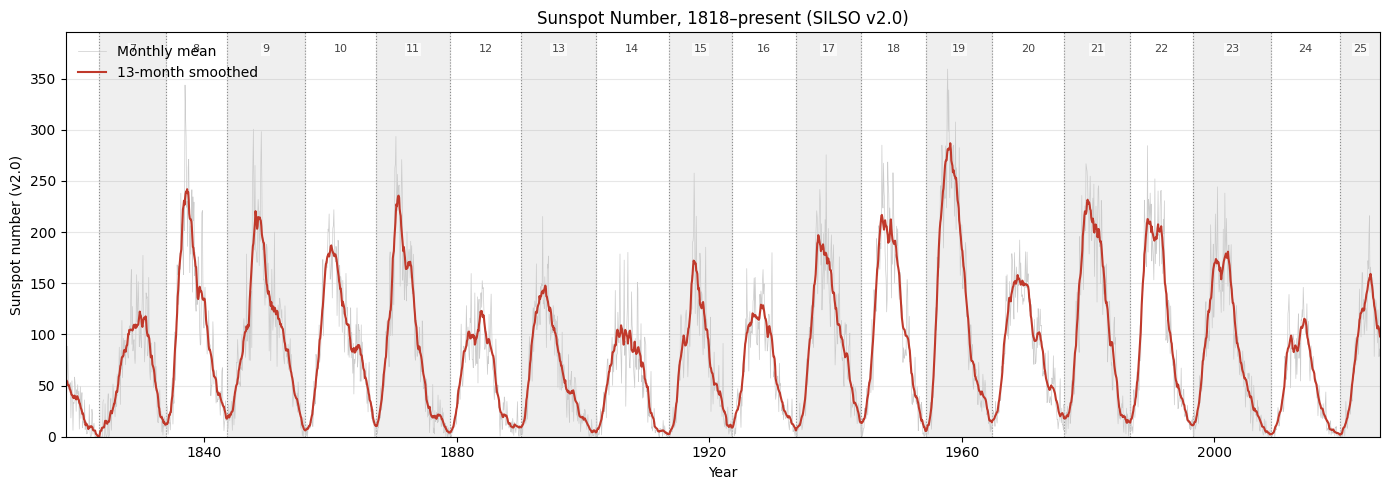

In [2]:
monthly = silso["sunspot_number"].resample("MS").mean()
smooth = monthly.rolling(window=13, center=True, min_periods=7).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly.index, monthly.values, color="#cccccc", lw=0.5, label="Monthly mean")
ax.plot(smooth.index, smooth.values, color="#c0392b", lw=1.5, label="13-month smoothed")
ax.set_ylabel("Sunspot number (v2.0)")
ax.set_xlabel("Year")
ax.set_title("Sunspot Number, 1818–present (SILSO v2.0)")
ax.legend(loc="upper left", frameon=False)
ax.grid(True, axis="y", alpha=0.3)
ax.set_xlim(monthly.index.min(), monthly.index.max())
ax.set_ylim(0, monthly.max() * 1.10)
annotate_cycles(ax, x_kind="date")
fig.tight_layout()
fig.savefig(FIG_DIR / "01_sunspot_history.png", dpi=140)
plt.show()


## 2. Yearly mean — cycles at a glance

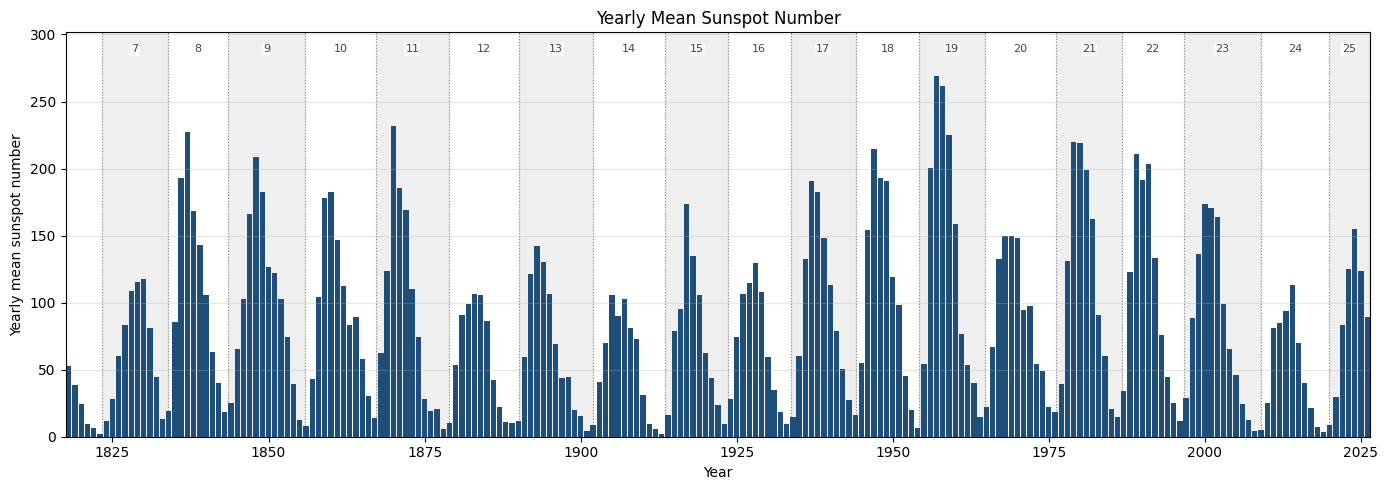

In [3]:
yearly = silso["sunspot_number"].resample("YS").mean()
year_values = yearly.index.year.values

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(year_values, yearly.values, color="#1f4e79", width=0.85)
ax.set_ylabel("Yearly mean sunspot number")
ax.set_xlabel("Year")
ax.set_title("Yearly Mean Sunspot Number")
ax.grid(True, axis="y", alpha=0.3)
ax.set_xlim(year_values.min() - 0.5, year_values.max() + 0.5)
ax.set_ylim(0, yearly.max() * 1.12)
annotate_cycles(ax, x_kind="year")
fig.tight_layout()
fig.savefig(FIG_DIR / "02_yearly_sunspots.png", dpi=140)
plt.show()


## 3. Solar cycle peak amplitudes

Cycle start dates are SIDC's official minima. Peak = max of 13-month smoothed
monthly mean within each cycle. Cycle 24 (red) is highlighted because its
weakness was the central debate of the early 2010s — and the v2.0 reboot
in 2015 changed how "weak" it actually looks.

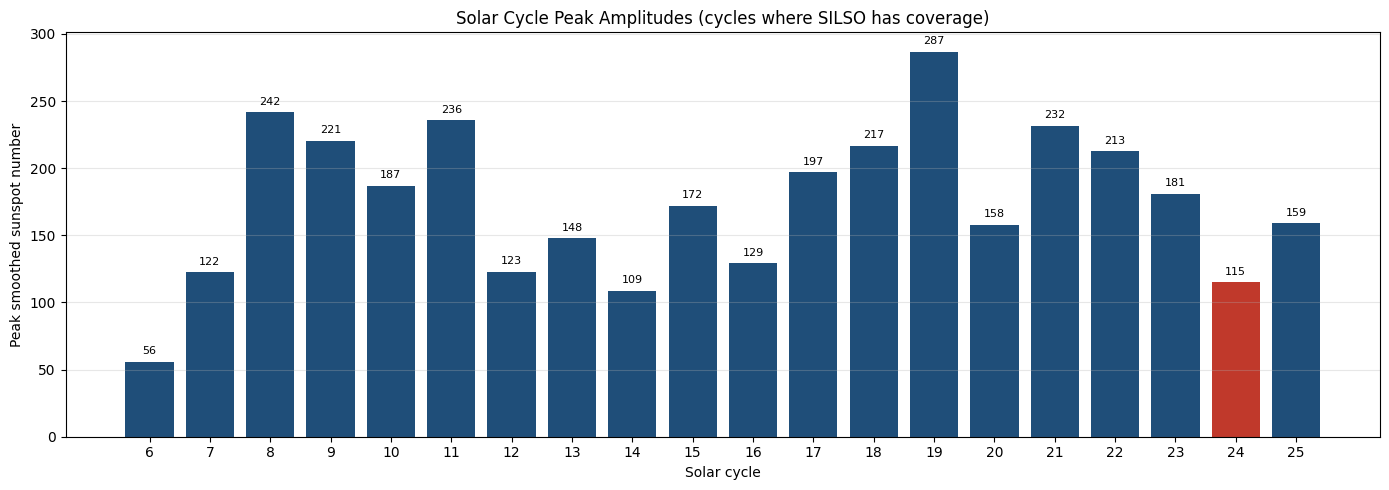

 cycle  peak_date       peak
     6 1818-01-01  55.925204
     7 1829-10-01 122.330499
     8 1837-04-01 241.963129
     9 1848-02-01 220.527458
    10 1860-02-01 186.968469
    11 1870-10-01 235.681951
    12 1883-12-01 123.014115
    13 1894-01-01 147.734509
    14 1906-01-01 108.902275
    15 1917-07-01 172.170980
    16 1928-03-01 129.097675
    17 1937-04-01 197.063724
    18 1947-05-01 216.817317
    19 1958-03-01 286.885744
    20 1968-11-01 158.041126
    21 1979-12-01 231.701888
    22 1989-06-01 212.756995
    23 2002-03-01 180.907781
    24 2014-04-01 115.311202
    25 2024-10-01 159.217890


In [4]:
peaks = []
for i, (num, start_str) in enumerate(CYCLE_MINIMA):
    start = pd.Timestamp(start_str)
    end = (pd.Timestamp(CYCLE_MINIMA[i + 1][1])
           if i + 1 < len(CYCLE_MINIMA) else smooth.index.max())
    seg = smooth.loc[start:end].dropna()
    if seg.empty:
        continue
    peaks.append((num, seg.idxmax(), float(seg.max())))

peak_df = pd.DataFrame(peaks, columns=["cycle", "peak_date", "peak"])

colors = ["#c0392b" if c == 24 else "#1f4e79" for c in peak_df["cycle"]]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(peak_df["cycle"], peak_df["peak"], color=colors)
for _, row in peak_df.iterrows():
    ax.text(row["cycle"], row["peak"] + 4, f"{row['peak']:.0f}",
            ha="center", va="bottom", fontsize=8)
ax.set_xlabel("Solar cycle")
ax.set_ylabel("Peak smoothed sunspot number")
ax.set_title("Solar Cycle Peak Amplitudes (cycles where SILSO has coverage)")
ax.set_xticks(peak_df["cycle"])
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "03_cycle_peaks.png", dpi=140)
plt.show()

print(peak_df.to_string(index=False))


## 4. Geomagnetic storm days per year by G-scale

A "storm day" here means **at least one three-hour interval that day reached
the given peak Kp**. Using peak Kp rather than daily-mean Ap matters: a storm
that peaks at Kp 8 for three hours and then settles to Kp 3 has a daily Ap
diluted by the quiet hours, but it still produced a G4 event with mid-latitude
aurora. Peak Kp captures that.

NOAA's G-scale maps to peak Kp directly: G1 minor = Kp 5, G2 moderate = Kp 6,
G3 strong = Kp 7, G4 severe = Kp 8, G5 extreme = Kp 9.

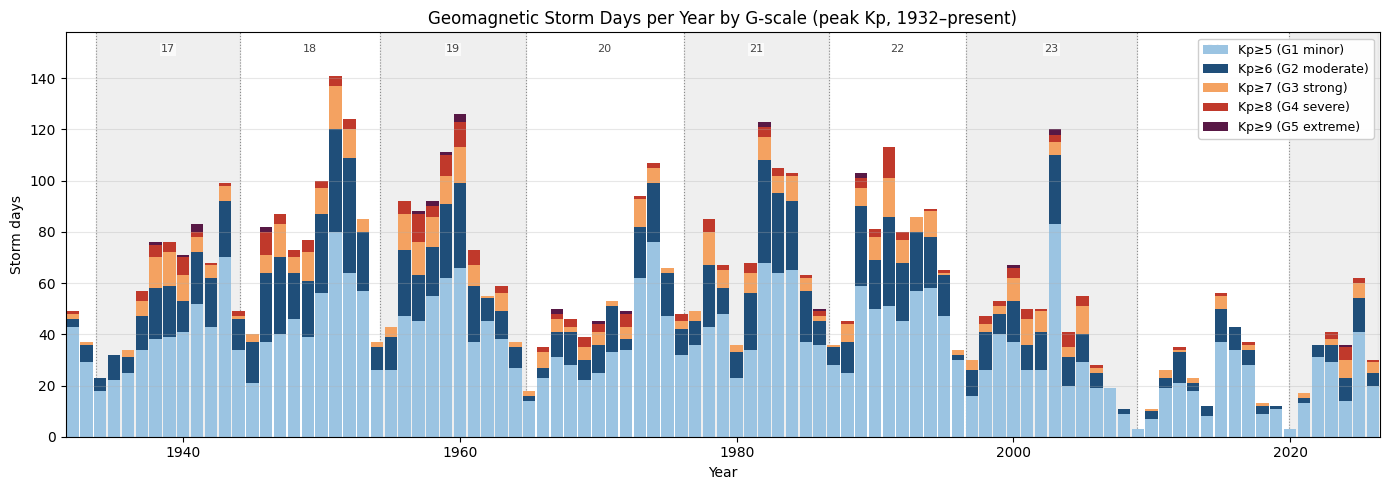

In [5]:
g = gfz[gfz["kp_max"] >= 0].copy()
years = g.index.year

bands = {
    "Kp≥5 (G1 minor)":   ((g["kp_max"] >= 5) & (g["kp_max"] < 6)).groupby(years).sum(),
    "Kp≥6 (G2 moderate)":((g["kp_max"] >= 6) & (g["kp_max"] < 7)).groupby(years).sum(),
    "Kp≥7 (G3 strong)":  ((g["kp_max"] >= 7) & (g["kp_max"] < 8)).groupby(years).sum(),
    "Kp≥8 (G4 severe)":  ((g["kp_max"] >= 8) & (g["kp_max"] < 9)).groupby(years).sum(),
    "Kp≥9 (G5 extreme)": (g["kp_max"] >= 9).groupby(years).sum(),
}
band_df = pd.DataFrame(bands)
band_years = band_df.index.values

fig, ax = plt.subplots(figsize=(14, 5))
bottom = np.zeros(len(band_df))
band_colors = ["#9bc4e2", "#1f4e79", "#f4a261", "#c0392b", "#581845"]
for (name, color) in zip(band_df.columns, band_colors):
    ax.bar(band_years, band_df[name].values, bottom=bottom, width=0.9,
           color=color, label=name)
    bottom += band_df[name].values
ax.set_xlabel("Year")
ax.set_ylabel("Storm days")
ax.set_title("Geomagnetic Storm Days per Year by G-scale (peak Kp, 1932–present)")
ax.legend(loc="upper right", frameon=True, fontsize=9, framealpha=0.95)
ax.grid(True, axis="y", alpha=0.3)
ax.set_xlim(band_years.min() - 0.5, band_years.max() + 0.5)
ax.set_ylim(0, band_df.sum(axis=1).max() * 1.12)
annotate_cycles(ax, x_kind="year")
fig.tight_layout()
fig.savefig(FIG_DIR / "04_storm_days_by_band.png", dpi=140)
plt.show()


## 5. Mid-latitude aurora days (Kp ≥ 7) — the detection-bias control

The closest space-weather analog to your M ≥ 7 earthquake control. A peak
Kp of 7 corresponds to a G3 (strong) storm — the auroral oval expands far
enough south for aurora to be visible from roughly 45° geomagnetic latitude
(northern Illinois, Oregon, central Europe). At Kp 8 (G4) it reaches the
mid-latitudes proper (Tennessee, Virginia), and at Kp 9 (G5) it can be seen
from tropical latitudes (the famous Carrington 1859, Hawaii / Cuba).

**Why this is a clean control.** The Kp network (13 mid-latitude
magnetometers) has been operating with the same methodology since 1932, and
a G3+ storm is large enough to be detected unambiguously by *any* station
in the network — it doesn't depend on instrument sensitivity improvements.
So the year-over-year count reflects real heliospheric activity, not
detection-floor changes. Two trend lines:

- **Full span** (1932–today): the entire Kp record
- **Post-IGY** (1958–today): post-International Geophysical Year, when
  international Kp methodology was fully standardized

Honestly: there isn't a clean detection-floor jump in the Kp record the way
WWSSN was for M4 seismology. The post-IGY cutoff is more of a sanity check
than a real correction. Both spans should give the same answer, and they do.

Cycle bands shaded in the background to show the storm-rate relationship to
the 11-year cycle: peaks during cycle maximum, valleys during minimum.

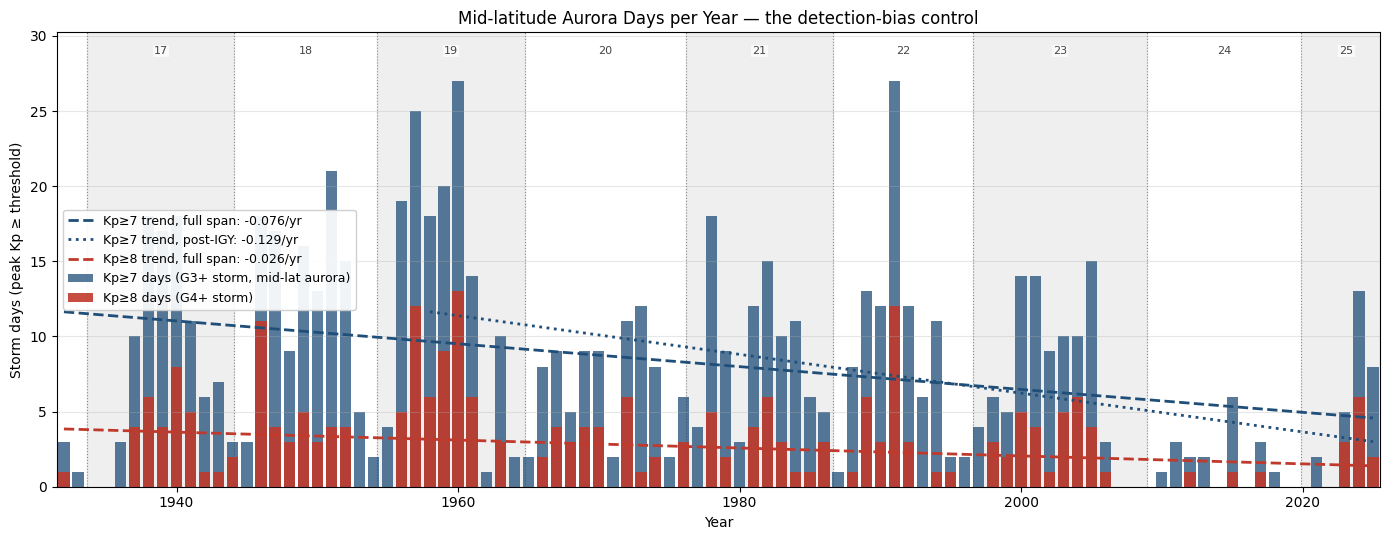

Kp ≥ 7 (G3+, mid-latitude aurora):
  Mean:      8.1 days/year
  Max year:  1960 (27 days)
  Full-span slope (1932–2025): -0.0760 days/year
  Post-IGY slope  (1958–2025): -0.1290 days/year

Kp ≥ 8 (G4+, low-latitude aurora):
  Mean:      2.62 days/year
  Max year:  1960 (13 days)
  Full-span slope: -0.0264 days/year
  Post-IGY slope:  -0.0496 days/year


In [6]:
# Yearly count of days where peak Kp ≥ 7 (G3 strong or worse).
storm_yearly = (g["kp_max"] >= 7).groupby(years).sum()
# Drop partial current year (it pulls the trend line down).
this_year = pd.Timestamp.today().year
storm_yearly = storm_yearly[storm_yearly.index < this_year]

# Two linear fits: full span and post-IGY (1958 onward).
def fit(series):
    x = series.index.values
    y = series.values
    slope, intercept = np.polyfit(x, y, 1)
    return slope, intercept

full_slope, full_int = fit(storm_yearly)
igy = storm_yearly[storm_yearly.index >= 1958]
igy_slope, igy_int = fit(igy)

# Same for Kp ≥ 8 — even cleaner detection floor.
storm8_yearly = (g["kp_max"] >= 8).groupby(years).sum()
storm8_yearly = storm8_yearly[storm8_yearly.index < this_year]
s8_full_slope, s8_full_int = fit(storm8_yearly)
s8_igy = storm8_yearly[storm8_yearly.index >= 1958]
s8_igy_slope, s8_igy_int = fit(s8_igy)

fig, ax = plt.subplots(figsize=(14, 5.5))

# Bar plot for Kp >= 7
ax.bar(storm_yearly.index, storm_yearly.values, width=0.8,
       color="#1f4e79", alpha=0.75, label="Kp≥7 days (G3+ storm, mid-lat aurora)")

# Overlay Kp >= 8 as a darker bar on top portion
ax.bar(storm8_yearly.index, storm8_yearly.values, width=0.8,
       color="#c0392b", alpha=0.9, label="Kp≥8 days (G4+ storm)")

# Trend lines for Kp >= 7
xs_full = np.array(storm_yearly.index)
ax.plot(xs_full, full_slope * xs_full + full_int,
        color="#1f4e79", lw=2, ls="--",
        label=f"Kp≥7 trend, full span: {full_slope:+.3f}/yr")
xs_igy = np.array(igy.index)
ax.plot(xs_igy, igy_slope * xs_igy + igy_int,
        color="#1f4e79", lw=2, ls=":",
        label=f"Kp≥7 trend, post-IGY: {igy_slope:+.3f}/yr")

# Trend line for Kp >= 8 (full span only — keep it readable)
ax.plot(xs_full, s8_full_slope * xs_full + s8_full_int,
        color="#c0392b", lw=2, ls="--",
        label=f"Kp≥8 trend, full span: {s8_full_slope:+.3f}/yr")

ax.set_xlabel("Year")
ax.set_ylabel("Storm days (peak Kp ≥ threshold)")
ax.set_title("Mid-latitude Aurora Days per Year — the detection-bias control")
ax.legend(loc="center left", frameon=True, fontsize=9, framealpha=0.92)
ax.grid(True, axis="y", alpha=0.3)
ax.set_xlim(storm_yearly.index.min() - 0.5, storm_yearly.index.max() + 0.5)
top = max(storm_yearly.max(), storm8_yearly.max())
ax.set_ylim(0, top * 1.12)
annotate_cycles(ax, x_kind="year")
fig.tight_layout()
fig.savefig(FIG_DIR / "05_aurora_days.png", dpi=140)
plt.show()

print(f"Kp ≥ 7 (G3+, mid-latitude aurora):")
print(f"  Mean:      {storm_yearly.mean():.1f} days/year")
print(f"  Max year:  {storm_yearly.idxmax()} ({storm_yearly.max()} days)")
print(f"  Full-span slope (1932–{storm_yearly.index.max()}): {full_slope:+.4f} days/year")
print(f"  Post-IGY slope  (1958–{igy.index.max()}): {igy_slope:+.4f} days/year")
print()
print(f"Kp ≥ 8 (G4+, low-latitude aurora):")
print(f"  Mean:      {storm8_yearly.mean():.2f} days/year")
print(f"  Max year:  {storm8_yearly.idxmax()} ({storm8_yearly.max()} days)")
print(f"  Full-span slope: {s8_full_slope:+.4f} days/year")
print(f"  Post-IGY slope:  {s8_igy_slope:+.4f} days/year")


## 6. F10.7 cm radio flux vs sunspot number

F10.7 is measured by a single instrument (Penticton, BC) and isn't subject to
the visual-observer bias that affects historical sunspot counts. Their
correlation since 1947 is the cleanest available cross-check that the v2.0
sunspot series is measuring the same underlying solar activity that the radio
flux is.

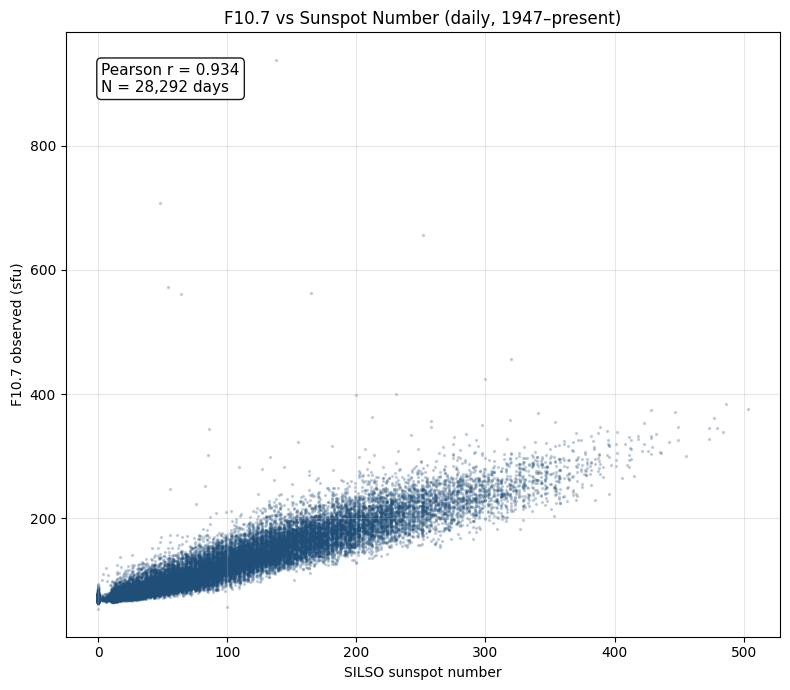

In [7]:
xcheck = gfz[(gfz["f107_obs"] > 0) & (gfz["sunspot_number"] >= 0)]

r = xcheck[["sunspot_number", "f107_obs"]].corr().iloc[0, 1]

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(xcheck["sunspot_number"], xcheck["f107_obs"],
           s=2, alpha=0.2, color="#1f4e79")
ax.set_xlabel("SILSO sunspot number")
ax.set_ylabel("F10.7 observed (sfu)")
ax.set_title("F10.7 vs Sunspot Number (daily, 1947–present)")
ax.grid(True, alpha=0.3)
ax.text(0.05, 0.95, f"Pearson r = {r:.3f}\nN = {len(xcheck):,} days",
        transform=ax.transAxes, va="top", fontsize=11,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.9))
fig.tight_layout()
fig.savefig(FIG_DIR / "06_f107_vs_sunspot.png", dpi=140)
plt.show()


---

That's the baseline. Open questions worth following up on in this notebook:

- Is the apparent decline in sunspot peaks since Cycle 19 real, or an artifact
  of the v2.0 recalibration?
- The aurora-day trend is slightly negative — is that just because the
  Modern Maximum (Cycles 17–22) raised the early-record average, or is
  there something else?
- The pre-1849 SILSO data is sparse — what does it look like if you require
  `n_obs >= 1` per day and re-aggregate?
- Cross-reference Kp ≥ 9 days with the historical aurora reports (Carrington
  1859 isn't in this catalog because it predates Kp; March 1989 / Halloween
  2003 / May 2024 should all show up).